# 🎓 THESIS PROJECT: VISUAL ANOMALY DETECTION
## NOTEBOOK 1: BASELINE MODELS & CONTROLLED BENCHMARKING

### Objective
This notebook establishes the **baseline performance floor** for visual anomaly detection on the MVTec AD `bottle` class. It compares two deliberately simple approaches:

1. **Classical baseline:** PCA + One-Class SVM.
2. **Deep-learning baseline:** a small undercomplete Convolutional Autoencoder (CAE).

The notebook is intentionally simpler than the later optimization and transfer-learning notebooks, but it follows the same engineering principles: explicit configuration, deterministic data handling, validation contracts, continuous anomaly scoring, leakage-aware threshold calibration, structured evaluation, and reproducible artifact export.

### Experimental contract
- **Training:** only normal (`good`) training images are used to fit either model.
- **Validation:** a held-out subset of normal training images is used for training monitoring and for operational threshold calibration.
- **Testing:** `test/good` and all defective test categories are never used for model fitting, threshold calibration, or model selection; final performance evaluation is performed in Block 8.
- **Label contract:** `0 = good`, `1 = anomaly`.
- **Score contract:** **higher score = more anomalous** for both models.
- **Primary ranking metric:** ROC-AUC from continuous anomaly scores.
- **Operational threshold:** calibrated from the normal validation-score distribution only; test labels are never used to choose the threshold.

This structure preserves the thesis narrative: Notebook 1 is a clean and defensible baseline, while later notebooks introduce optimization, SSIM-focused analysis, transfer learning, explainability, and deployment.

### BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION

**OBJECTIVE:**  
Initialize a self-contained execution environment and define a single configuration contract used throughout the notebook.

**ENGINEERING PRINCIPLES:**
- Centralize experiment parameters instead of scattering magic numbers across cells.
- Keep Kaggle's standard Python / NumPy / pandas import path unchanged.
- Enable deterministic TensorFlow operations after the normal library imports.
- Re-seed model initialization and training-order randomness exactly where those stochastic operations are consumed.
- Keep the baseline model intentionally fixed: no hyperparameter search, no callbacks, and no advanced regularization. Those belong to the optimization notebook.

**GLOBAL CONTRACT:**
- `IMG_SIZE = (128, 128)`
- `TARGET_CLASS = "bottle"`
- `SEED = 42`
- `NORMAL_LABEL = 0`, `ANOMALY_LABEL = 1`
- Higher anomaly score always means “more anomalous”.

**REPRODUCIBILITY NOTE:**  
The autoencoder uses explicit initializer seeds and a seeded deterministic `tf.data` shuffle. This avoids dependence on how much random state earlier notebook operations have consumed while preserving the original scientific protocol.


In [1]:
# ==========================================================================================================================================================
# BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION
# ==========================================================================================================================================================

print("INITIALIZING BASELINE EXPERIMENT ENVIRONMENT...\n")
print("ACTION: Loading dependencies, configuration and reproducibility controls.\n")


# REQUIRED MODULE IMPORTS

import json
import random
import tarfile
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import img_to_array, load_img


# GLOBAL CONFIGURATION

SEED = 42
IMG_SIZE = (128, 128)
TARGET_CLASS = "bottle"

NORMAL_LABEL = 0
ANOMALY_LABEL = 1

VALIDATION_FRACTION = 0.20
TARGET_VALIDATION_FPR = 0.05

PCA_VARIANCE_TARGET = 0.95
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"

BASELINE_LEARNING_RATE = 1e-3
BASELINE_EPOCHS = 50
BASELINE_BATCH_SIZE = 32

IMAGE_EXTENSIONS = {".png"}

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORK_ROOT = Path("/kaggle/working")
PREFERRED_ARCHIVE_NAME = "mvtec_anomaly_detection.tar.xz"

ARTIFACT_DIR = KAGGLE_WORK_ROOT / "notebook1_artifacts"
BASELINE_METRICS_PATH = KAGGLE_WORK_ROOT / "baseline_metrics.json"


# REPRODUCIBILITY CONFIGURATION

def reset_reproducibility(seed=SEED, clear_session=False):
    """Reset Python, NumPy and TensorFlow RNG state at a controlled experiment boundary."""

    seed = int(seed)

    if clear_session:
        tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    return seed


reset_reproducibility(SEED)
tf.config.experimental.enable_op_determinism()


# CONFIGURATION INTEGRITY CHECKS

if not isinstance(IMG_SIZE, tuple) or len(IMG_SIZE) != 2 or any(int(v) <= 0 for v in IMG_SIZE):
    raise ValueError(f"BLOCK 1 CONFIGURATION FAILURE: invalid IMG_SIZE={IMG_SIZE!r}")

if not (0.0 < VALIDATION_FRACTION < 1.0):
    raise ValueError("BLOCK 1 CONFIGURATION FAILURE: VALIDATION_FRACTION must be between 0 and 1.")

if not (0.0 < TARGET_VALIDATION_FPR < 1.0):
    raise ValueError("BLOCK 1 CONFIGURATION FAILURE: TARGET_VALIDATION_FPR must be between 0 and 1.")


print("CONFIGURATION SUMMARY")
print(f"  Target class          : {TARGET_CLASS}")
print(f"  Image size            : {IMG_SIZE}")
print(f"  Random seed           : {SEED}")
print(f"  Validation fraction   : {VALIDATION_FRACTION:.0%}")
print(f"  Target validation FPR : {TARGET_VALIDATION_FPR:.0%}")
print("\n✅ BLOCK 1 COMPLETED: Environment and experiment contract initialized.")


INITIALIZING BASELINE EXPERIMENT ENVIRONMENT...

ACTION: Loading dependencies, configuration and reproducibility controls.

CONFIGURATION SUMMARY
  Target class          : bottle
  Image size            : (128, 128)
  Random seed           : 42
  Validation fraction   : 20%
  Target validation FPR : 5%

✅ BLOCK 1 COMPLETED: Environment and experiment contract initialized.


### BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION

**OBJECTIVE:**  
Resolve the MVTec AD `bottle` dataset without depending on a specific Kaggle dataset slug or mounted folder name.

**DISCOVERY STRATEGY:**  

1. **Reuse already extracted data** from `/kaggle/working` when a valid MVTec class directory is present.
2. **Use directly mounted image folders** from `/kaggle/input` when Kaggle exposes the dataset already unpacked.
3. **Discover a compatible archive automatically** anywhere under `/kaggle/input` and extract it only when necessary.
4. **Validate the resolved class contract** before continuing:
   - `train/good`
   - `test/good`
   - at least one defective test category

The final `BASE_DIR` may therefore point either to Kaggle's read-only input storage or to the writable working directory. Downstream blocks only read images from `BASE_DIR`, so both layouts are valid.

If discovery fails, the block reports the mounted input entries it inspected instead of assuming a dataset path.


In [2]:
# ==========================================================================================================================================================
# BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION
# ==========================================================================================================================================================

print("RESOLVING MVTEC DATASET STRUCTURE...\n")
print("ACTION: Discovering the target class independently of Kaggle dataset slug or archive layout.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_2_objects = [
    "KAGGLE_INPUT_ROOT",
    "KAGGLE_WORK_ROOT",
    "TARGET_CLASS",
    "PREFERRED_ARCHIVE_NAME",
]

_missing_block_2_objects = [
    object_name
    for object_name in _required_block_2_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_2_objects:
    raise RuntimeError(
        "BLOCK 2 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_2_objects}. Run Block 1 first."
    )


# DATASET DISCOVERY HELPERS

def is_valid_mvtec_class_dir(candidate):
    """Return True when a directory satisfies the minimum MVTec class contract."""

    candidate = Path(candidate)

    return (
        candidate.is_dir()
        and (candidate / "train" / "good").is_dir()
        and (candidate / "test" / "good").is_dir()
    )


def find_target_class_dir(search_root):
    """Search one root for the target class while preferring shallow deterministic matches."""

    search_root = Path(search_root)

    if not search_root.is_dir():
        return None

    # Fast-path candidates for the most common MVTec layouts.
    direct_candidates = [
        search_root / TARGET_CLASS,
        search_root / "mvtec_anomaly_detection" / TARGET_CLASS,
        search_root / "mvtec_ad" / TARGET_CLASS,
        search_root / "mvtec-ad" / TARGET_CLASS,
    ]

    for candidate in direct_candidates:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    # Portable fallback: locate directories named exactly as the requested class.
    candidate_dirs = sorted(
        (
            path
            for path in search_root.rglob(TARGET_CLASS)
            if path.is_dir()
        ),
        key=lambda path: (len(path.parts), str(path)),
    )

    for candidate in candidate_dirs:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    return None


def discover_mvtec_archive(search_root):
    """Return the most plausible MVTec archive available under a Kaggle input root."""

    search_root = Path(search_root)

    if not search_root.is_dir():
        return None

    archives = sorted(
        (
            path
            for path in search_root.rglob("*.tar.xz")
            if path.is_file()
        ),
        key=str,
    )

    if not archives:
        return None

    def archive_rank(path):
        name = path.name.lower()
        parent_text = str(path.parent).lower()

        exact_name = int(name == PREFERRED_ARCHIVE_NAME.lower())
        mentions_mvtec = int("mvtec" in name or "mvtec" in parent_text)
        mentions_target = int(TARGET_CLASS.lower() in name)

        # Lower tuple is preferred; negative scores put stronger matches first.
        return (
            -exact_name,
            -mentions_mvtec,
            -mentions_target,
            len(path.parts),
            str(path),
        )

    return sorted(archives, key=archive_rank)[0]


# STAGE 1: REUSE ALREADY EXTRACTED DATA

BASE_DIR = find_target_class_dir(KAGGLE_WORK_ROOT)
dataset_source = "kaggle_working"


# STAGE 2: USE DIRECTLY MOUNTED / UNPACKED INPUT DATA

if BASE_DIR is None:
    BASE_DIR = find_target_class_dir(KAGGLE_INPUT_ROOT)
    dataset_source = "kaggle_input_direct" if BASE_DIR is not None else None


# STAGE 3: DISCOVER AND EXTRACT ARCHIVE ONLY WHEN REQUIRED

if BASE_DIR is None:

    archive_path = discover_mvtec_archive(KAGGLE_INPUT_ROOT)

    if archive_path is None:

        mounted_entries = []

        if KAGGLE_INPUT_ROOT.is_dir():
            mounted_entries = sorted(
                path.name
                for path in KAGGLE_INPUT_ROOT.iterdir()
            )

        raise FileNotFoundError(
            "BLOCK 2 DATASET FAILURE: no valid MVTec "
            f"'{TARGET_CLASS}' directory and no compatible .tar.xz archive were found "
            f"under {KAGGLE_INPUT_ROOT}. Mounted input entries: {mounted_entries}. "
            "Verify that the MVTec AD dataset is attached to this Kaggle notebook."
        )

    print(f"Discovered dataset archive: {archive_path}")
    print("Extracting archive to Kaggle working storage...\n")

    with tarfile.open(archive_path, mode="r:*") as archive:
        archive.extractall(KAGGLE_WORK_ROOT, filter="data")

    BASE_DIR = find_target_class_dir(KAGGLE_WORK_ROOT)
    dataset_source = "extracted_archive"


# FINAL DATASET CONTRACT VALIDATION

if BASE_DIR is None or not is_valid_mvtec_class_dir(BASE_DIR):
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: dataset discovery/extraction completed, "
        f"but a valid '{TARGET_CLASS}' MVTec class structure could not be resolved."
    )


TRAIN_GOOD_DIR = BASE_DIR / "train" / "good"
TEST_DIR = BASE_DIR / "test"
TEST_GOOD_DIR = TEST_DIR / "good"

defect_categories = sorted(
    path.name
    for path in TEST_DIR.iterdir()
    if path.is_dir() and path.name != "good"
)

if not defect_categories:
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: the resolved test directory contains no defective categories."
    )


print("DATASET RESOLUTION SUMMARY")
print(f"  Source mode       : {dataset_source}")
print(f"  Resolved class dir: {BASE_DIR}")
print(f"  Train/good        : {TRAIN_GOOD_DIR}")
print(f"  Test/good         : {TEST_GOOD_DIR}")
print(f"  Defect categories : {defect_categories}")

print("\n✅ BLOCK 2 COMPLETED: Dataset structure discovered and validated.")


RESOLVING MVTEC DATASET STRUCTURE...

ACTION: Discovering the target class independently of Kaggle dataset slug or archive layout.

Discovered dataset archive: /kaggle/input/datasets/chrysoulatsitsifa/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz
Extracting archive to Kaggle working storage...

DATASET RESOLUTION SUMMARY
  Source mode       : extracted_archive
  Resolved class dir: /kaggle/working/bottle
  Train/good        : /kaggle/working/bottle/train/good
  Test/good         : /kaggle/working/bottle/test/good
  Defect categories : ['broken_large', 'broken_small', 'contamination']

✅ BLOCK 2 COMPLETED: Dataset structure discovered and validated.


### BLOCK 3: DATA LOADING, VALIDATION & SPLIT DEFINITION

**OBJECTIVE:**  
Create the notebook's data contract once and reuse it consistently across both baselines.

**PIPELINE:**
1. Load RGB `.png` images in sorted filename order.
2. Resize to `IMG_SIZE`.
3. Convert to `float32` and normalize pixel values to `[0, 1]`.
4. Preserve the original defect category for every anomalous test sample.
5. Split the original `train/good` pool into:
   - `train_images`: normal samples used for model fitting.
   - `validation_images`: normal samples used for monitoring and threshold calibration.
6. Construct one final test set with labels `0 = good`, `1 = anomaly`.

**INTEGRITY AUDIT:**  
Shapes, dtypes, finite values, ranges, sample counts, and label/category alignment are checked before training starts. Invalid or empty data causes a hard failure rather than a silent fallback.

In [3]:
# ==========================================================================================================================================================
# BLOCK 3: DATA LOADING, VALIDATION & SPLIT DEFINITION
# ==========================================================================================================================================================

print("EXECUTING DATA INGESTION & VALIDATION PIPELINE...\n")
print("ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.\n")


def load_image_directory(folder_path):
    """Load one image directory into a deterministic float32 RGB tensor."""

    folder_path = Path(folder_path)

    if not folder_path.is_dir():
        raise FileNotFoundError(f"Image directory does not exist: {folder_path}")

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if not image_paths:
        raise RuntimeError(f"No supported images found in: {folder_path}")

    images = np.empty(
        (len(image_paths), IMG_SIZE[0], IMG_SIZE[1], 3),
        dtype=np.float32,
    )

    for index, image_path in enumerate(image_paths):
        image = load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
        image = img_to_array(image).astype(np.float32) / 255.0
        images[index] = image

    return images, [str(path) for path in image_paths]


def validate_image_batch(batch_name, images):
    """Validate tensor schema and numerical range for one image batch."""

    expected_tail = (IMG_SIZE[0], IMG_SIZE[1], 3)

    if not isinstance(images, np.ndarray):
        raise TypeError(f"{batch_name}: expected numpy.ndarray, received {type(images).__name__}.")

    if images.ndim != 4 or tuple(images.shape[1:]) != expected_tail:
        raise ValueError(
            f"{batch_name}: expected shape (N, {expected_tail}), received {images.shape}."
        )

    if len(images) == 0:
        raise ValueError(f"{batch_name}: batch is empty.")

    if images.dtype != np.float32:
        raise TypeError(f"{batch_name}: expected float32, received {images.dtype}.")

    if not np.isfinite(images).all():
        raise ValueError(f"{batch_name}: NaN or infinite values detected.")

    if float(images.min()) < 0.0 or float(images.max()) > 1.0:
        raise ValueError(f"{batch_name}: normalized pixel values must remain inside [0, 1].")


# LOAD NORMAL TRAINING POOL

train_pool_images, train_pool_paths = load_image_directory(TRAIN_GOOD_DIR)
test_good, test_good_paths = load_image_directory(TEST_GOOD_DIR)


# LOAD ALL DEFECT CATEGORIES WHILE PRESERVING CATEGORY IDENTITY

test_bad_batches = []
test_bad_paths = []
test_bad_categories_list = []

dataset_rows = [
    {"split": "train", "category": "good", "samples": len(train_pool_images)},
    {"split": "test", "category": "good", "samples": len(test_good)},
]

for category in defect_categories:

    category_images, category_paths = load_image_directory(TEST_DIR / category)

    test_bad_batches.append(category_images)
    test_bad_paths.extend(category_paths)
    test_bad_categories_list.extend([category] * len(category_images))

    dataset_rows.append(
        {"split": "test", "category": category, "samples": len(category_images)}
    )

test_bad = np.concatenate(test_bad_batches, axis=0).astype(np.float32, copy=False)
test_bad_categories = np.asarray(test_bad_categories_list, dtype=object)


# NORMAL-ONLY TRAIN / VALIDATION SPLIT

train_indices, validation_indices = train_test_split(
    np.arange(len(train_pool_images)),
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
)

train_images = train_pool_images[train_indices]
validation_images = train_pool_images[validation_indices]

train_paths = [train_pool_paths[index] for index in train_indices]
validation_paths = [train_pool_paths[index] for index in validation_indices]


# FINAL TEST CONTRACT

test_images = np.concatenate((test_good, test_bad), axis=0).astype(np.float32, copy=False)

test_labels = np.concatenate(
    (
        np.full(len(test_good), NORMAL_LABEL, dtype=np.int8),
        np.full(len(test_bad), ANOMALY_LABEL, dtype=np.int8),
    )
)

test_categories = np.concatenate(
    (
        np.full(len(test_good), "good", dtype=object),
        test_bad_categories,
    )
)


# DATA INTEGRITY AUDIT

for batch_name, images in {
    "train_images": train_images,
    "validation_images": validation_images,
    "test_good": test_good,
    "test_bad": test_bad,
    "test_images": test_images,
}.items():
    validate_image_batch(batch_name, images)

if len(test_images) != len(test_labels) or len(test_images) != len(test_categories):
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: test image/label/category lengths are inconsistent.")

if set(np.unique(test_labels)) != {NORMAL_LABEL, ANOMALY_LABEL}:
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: final test set does not contain both label classes.")


dataset_audit = pd.DataFrame(dataset_rows)
dataset_audit["share_of_split"] = (
    dataset_audit["samples"]
    / dataset_audit.groupby("split")["samples"].transform("sum")
)

split_audit = pd.DataFrame(
    [
        {"data_object": "train_images", "role": "normal-only model fitting", "samples": len(train_images)},
        {"data_object": "validation_images", "role": "normal-only monitoring / threshold calibration", "samples": len(validation_images)},
        {"data_object": "test_good", "role": "final normal evaluation", "samples": len(test_good)},
        {"data_object": "test_bad", "role": "final anomaly evaluation", "samples": len(test_bad)},
    ]
)

print("DATASET CATEGORY AUDIT")
display(dataset_audit)

print("\nEXPERIMENT SPLIT AUDIT")
display(split_audit)

print(
    f"\nTensor contract: {IMG_SIZE[0]}x{IMG_SIZE[1]}x3, "
    f"dtype={train_images.dtype}, range=[{train_images.min():.3f}, {train_images.max():.3f}]"
)

print("\n✅ BLOCK 3 COMPLETED: Data contract validated with no test leakage into training or threshold calibration.")


EXECUTING DATA INGESTION & VALIDATION PIPELINE...

ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.

DATASET CATEGORY AUDIT


,split,category,samples,share_of_split
0,train,good,209,1.000000
1,test,good,20,0.240964
2,test,broken_large,20,0.240964
3,test,broken_small,22,0.265060
4,test,contamination,21,0.253012



EXPERIMENT SPLIT AUDIT


,data_object,role,samples
0,train_images,normal-only model fitting,167
1,validation_images,normal-only monitoring / threshold calibration,42
2,test_good,final normal evaluation,20
3,test_bad,final anomaly evaluation,63



Tensor contract: 128x128x3, dtype=float32, range=[0.098, 1.000]

✅ BLOCK 3 COMPLETED: Data contract validated with no test leakage into training or threshold calibration.


### BLOCK 4: DEVELOPMENT-DATA SANITY CHECK

**OBJECTIVE:**  
Verify the statistical consistency of the normal development subsets before model fitting, without opening or visualizing the final test set.

**CHECKS:**
- Compare train and validation sample counts.
- Compare normalized pixel mean, standard deviation, minimum, and maximum.
- Verify that both subsets remain finite and within the expected `[0, 1]` normalization range.

No matplotlib visualization is produced in this block. The notebook's visual dataset comparison is intentionally shown **once only**, in Block 8, after both baseline models and their thresholds have already been fixed.


In [4]:
# ==========================================================================================================================================================
# BLOCK 4: DEVELOPMENT-DATA SANITY CHECK
# ==========================================================================================================================================================

print("INITIATING DEVELOPMENT-DATA SANITY CHECK...\n")
print("ACTION: Verifying normal train/validation statistics while keeping final test data unopened for evaluation.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_4_objects = [
    "train_images",
    "validation_images",
]

_missing_block_4_objects = [
    object_name
    for object_name in _required_block_4_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_4_objects:
    raise RuntimeError(
        "BLOCK 4 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_4_objects}. Run the notebook sequentially from Block 1."
    )


# NORMAL DEVELOPMENT STATISTICAL AUDIT

development_summary = pd.DataFrame(
    [
        {
            "subset": "Normal (Train)",
            "samples": int(len(train_images)),
            "mean_pixel": float(train_images.mean()),
            "std_pixel": float(train_images.std()),
            "min_pixel": float(train_images.min()),
            "max_pixel": float(train_images.max()),
        },
        {
            "subset": "Normal (Validation)",
            "samples": int(len(validation_images)),
            "mean_pixel": float(validation_images.mean()),
            "std_pixel": float(validation_images.std()),
            "min_pixel": float(validation_images.min()),
            "max_pixel": float(validation_images.max()),
        },
    ]
)

display(development_summary)


# DEVELOPMENT CONTRACT VALIDATION

for subset_name, subset in {
    "train_images": train_images,
    "validation_images": validation_images,
}.items():

    if subset.ndim != 4 or subset.shape[-1] != 3:
        raise RuntimeError(
            "BLOCK 4 SHAPE FAILURE: "
            f"{subset_name} has invalid shape {subset.shape}; expected [N, H, W, 3]."
        )

    if not np.isfinite(subset).all():
        raise RuntimeError(
            "BLOCK 4 NUMERICAL FAILURE: "
            f"{subset_name} contains non-finite values."
        )

    subset_min = float(subset.min())
    subset_max = float(subset.max())

    if subset_min < 0.0 or subset_max > 1.0:
        raise RuntimeError(
            "BLOCK 4 RANGE FAILURE: "
            f"{subset_name} range is [{subset_min:.6f}, {subset_max:.6f}], expected [0, 1]."
        )


print(
    "\nNOTE: No final-test images are visualized here. "
    "The Normal-vs-Anomaly sample grid and intensity distribution are shown once, in Block 8."
)

print("\n✅ BLOCK 4 COMPLETED: Normal development-data sanity checks passed.")


INITIATING DEVELOPMENT-DATA SANITY CHECK...

ACTION: Verifying normal train/validation statistics while keeping final test data unopened for evaluation.



,subset,samples,mean_pixel,std_pixel,min_pixel,max_pixel
0,Normal (Train),167,0.538412,0.361365,0.098039,1.0
1,Normal (Validation),42,0.539706,0.361141,0.098039,1.0



NOTE: No final-test images are visualized here. The Normal-vs-Anomaly sample grid and intensity distribution are shown once, in Block 8.

✅ BLOCK 4 COMPLETED: Normal development-data sanity checks passed.


### BLOCK 5: CLASSICAL BASELINE — PCA + ONE-CLASS SVM

**OBJECTIVE:**  
Fit and calibrate the classical anomaly-detection baseline using only normal development data. Final test evaluation remains deferred until Block 8.

**METHODOLOGY:**

1. **Vectorization:** RGB images are flattened from `128 × 128 × 3 = 49,152` input values into 1D feature vectors.
2. **PCA:** fitted **only on training images** and configured to retain 95% of training variance.
3. **One-Class SVM:** fitted only on the PCA representation of normal training data with fixed baseline settings (`RBF`, `gamma='scale'`, `nu=0.05`).
4. **Continuous anomaly score:** the One-Class SVM decision function is negated so that higher values always mean “more anomalous”.
5. **Operational threshold:** calibrated from the upper tail of the normal validation-score distribution only. The empirical quantile uses the `higher` method so that finite validation samples do not exceed the nominal false-positive target solely because of interpolation.

No test labels are used here, and no PCA/SVM hyperparameter tuning is performed.


In [5]:
# ==========================================================================================================================================================
# BLOCK 5: CLASSICAL BASELINE — PCA + ONE-CLASS SVM
# ==========================================================================================================================================================

print("INITIATING CLASSICAL BASELINE PIPELINE...\n")
print("ACTION: Fitting PCA + One-Class SVM and calibrating the anomaly threshold on normal validation data.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_5_objects = [
    "train_images",
    "validation_images",
    "PCA_VARIANCE_TARGET",
    "OCSVM_NU",
    "OCSVM_GAMMA",
    "TARGET_VALIDATION_FPR",
]

_missing_block_5_objects = [
    object_name
    for object_name in _required_block_5_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_5_objects:
    raise RuntimeError(
        "BLOCK 5 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_5_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


# SHARED THRESHOLD CALIBRATION HELPER

def calibrate_normal_threshold(normal_scores, target_fpr):
    """
    Calibrate an upper-tail anomaly threshold using normal validation scores only.

    The higher empirical quantile prevents linear interpolation from producing
    an observed validation flag rate above the nominal target purely because
    the validation set is finite.
    """

    normal_scores = np.asarray(
        normal_scores,
        dtype=float,
    ).reshape(-1)

    if normal_scores.size == 0:
        raise ValueError(
            "Threshold calibration requires at least one validation score."
        )

    if not np.isfinite(normal_scores).all():
        raise ValueError(
            "Threshold calibration received non-finite validation scores."
        )

    if not (0.0 < target_fpr < 1.0):
        raise ValueError(
            "target_fpr must be strictly between 0 and 1."
        )

    threshold = float(
        np.quantile(
            normal_scores,
            1.0 - target_fpr,
            method="higher",
        )
    )

    observed_flag_rate = float(
        np.mean(
            normal_scores > threshold
        )
    )

    return threshold, observed_flag_rate


# FEATURE VECTORIZATION — DEVELOPMENT DATA ONLY

train_flat = train_images.reshape(
    len(train_images),
    -1,
)

validation_flat = validation_images.reshape(
    len(validation_images),
    -1,
)


# PCA FIT — TRAINING DATA ONLY

pca_model = PCA(
    n_components=PCA_VARIANCE_TARGET,
    svd_solver="full",
)

train_pca = pca_model.fit_transform(
    train_flat
)

validation_pca = pca_model.transform(
    validation_flat
)

retained_variance = float(
    np.sum(
        pca_model.explained_variance_ratio_
    )
)

if (
    not np.isfinite(train_pca).all()
    or not np.isfinite(validation_pca).all()
):
    raise RuntimeError(
        "BLOCK 5 PCA FAILURE: non-finite transformed features detected."
    )


# ONE-CLASS SVM FIT — NORMAL TRAINING DATA ONLY

svm_model = OneClassSVM(
    kernel="rbf",
    gamma=OCSVM_GAMMA,
    nu=OCSVM_NU,
)

svm_model.fit(
    train_pca
)


# CONTINUOUS VALIDATION ANOMALY SCORES
# OneClassSVM decision_function:
# positive = inlier, negative = outlier.
# Negation enforces the notebook-wide contract: higher score = more anomalous.

svm_validation_scores = -svm_model.decision_function(
    validation_pca
)

if not np.isfinite(svm_validation_scores).all():
    raise RuntimeError(
        "BLOCK 5 SCORING FAILURE: non-finite validation anomaly scores detected."
    )


# VALIDATION-ONLY OPERATIONAL THRESHOLD

svm_threshold, svm_validation_flag_rate = calibrate_normal_threshold(
    svm_validation_scores,
    TARGET_VALIDATION_FPR,
)


# CLASSICAL BASELINE SUMMARY

pca_summary = pd.DataFrame(
    [
        {
            "input_features": int(train_flat.shape[1]),
            "pca_features": int(train_pca.shape[1]),
            "retained_variance": retained_variance,
            "svm_nu": OCSVM_NU,
            "validation_threshold": svm_threshold,
            "validation_flag_rate": svm_validation_flag_rate,
        }
    ]
)

display(pca_summary)


print(
    f"\nPCA reduced {train_flat.shape[1]:,} input values to "
    f"{train_pca.shape[1]:,} components while retaining "
    f"{retained_variance:.2%} variance."
)

print(
    f"SVM validation threshold : {svm_threshold:.8f}\n"
    f"Validation flag rate     : {svm_validation_flag_rate:.2%} "
    f"(target ≤ {TARGET_VALIDATION_FPR:.2%})"
)

print(
    "\n✅ BLOCK 5 COMPLETED: Classical baseline fitted and calibrated; "
    "final test evaluation remains sealed."
)


INITIATING CLASSICAL BASELINE PIPELINE...

ACTION: Fitting PCA + One-Class SVM and calibrating the anomaly threshold on normal validation data.



,input_features,pca_features,retained_variance,svm_nu,validation_threshold,validation_flag_rate
0,49152,124,0.95081,0.05,0.059391,0.047619



PCA reduced 49,152 input values to 124 components while retaining 95.08% variance.
SVM validation threshold : 0.05939078
Validation flag rate     : 4.76% (target ≤ 5.00%)

✅ BLOCK 5 COMPLETED: Classical baseline fitted and calibrated; final test evaluation remains sealed.


### BLOCK 6: DEEP-LEARNING BASELINE — SIMPLE CONVOLUTIONAL AUTOENCODER

**OBJECTIVE:**  
Define a deliberately small **undercomplete** convolutional autoencoder as the deep-learning baseline.

**ARCHITECTURAL RATIONALE:**
- The encoder reduces spatial resolution through two pooling stages.
- The latent feature map uses fewer total activations than the original input, creating a genuine representational bottleneck rather than only a smaller spatial map.
- The decoder reconstructs the image with a symmetric upsampling path.
- `sigmoid` output matches the `[0, 1]` input range.
- Fixed Adam learning rate and MSE reconstruction loss keep the baseline simple.

**REPRODUCIBILITY CONTROL:**  
Immediately before model construction, the Keras session and random generators are reset. Every trainable convolution uses an explicit Glorot-uniform initializer seed derived from the global experiment seed, so the initial weights do not depend on earlier RNG consumption.

This notebook does **not** add Batch Normalization, Dropout, callbacks, architecture search, or learning-rate tuning. Those remain meaningful improvements for the subsequent optimization notebook.


In [6]:
# ==========================================================================================================================================================
# BLOCK 6: DEEP-LEARNING BASELINE — SIMPLE CONVOLUTIONAL AUTOENCODER
# ==========================================================================================================================================================

print("CONSTRUCTING SIMPLE CONVOLUTIONAL AUTOENCODER...\n")
print("ACTION: Building an intentionally small undercomplete encoder-decoder baseline.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_6_objects = [
    "IMG_SIZE",
    "BASELINE_LEARNING_RATE",
    "SEED",
    "reset_reproducibility",
]

_missing_block_6_objects = [
    object_name
    for object_name in _required_block_6_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_6_objects:
    raise RuntimeError(
        "BLOCK 6 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_6_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


# DETERMINISTIC MODEL-INITIALIZATION BOUNDARY

reset_reproducibility(
    SEED,
    clear_session=True,
)


# MODEL ARCHITECTURE
# Explicit initializer seeds make initial weights independent of earlier RNG consumption.

input_tensor = Input(
    shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    name="input_image",
)

x = Conv2D(
    32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 1),
    name="encoder_conv_1",
)(input_tensor)

x = MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="encoder_pool_1",
)(x)

x = Conv2D(
    16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 2),
    name="encoder_conv_2",
)(x)

encoded = MaxPooling2D(
    pool_size=(2, 2),
    padding="same",
    name="latent_map",
)(x)

x = Conv2D(
    16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 3),
    name="decoder_conv_1",
)(encoded)

x = UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_1",
)(x)

x = Conv2D(
    32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same",
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 4),
    name="decoder_conv_2",
)(x)

x = UpSampling2D(
    size=(2, 2),
    name="decoder_upsample_2",
)(x)

decoded = Conv2D(
    3,
    kernel_size=(3, 3),
    activation="sigmoid",
    padding="same",
    kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED + 5),
    name="reconstruction",
)(x)


# MODEL COMPILATION

model = Model(
    inputs=input_tensor,
    outputs=decoded,
    name="simple_convolutional_autoencoder",
)

model.compile(
    optimizer=Adam(learning_rate=BASELINE_LEARNING_RATE),
    loss="mse",
)


# BOTTLENECK INTEGRITY CHECK

input_value_count = int(
    np.prod(
        (IMG_SIZE[0], IMG_SIZE[1], 3)
    )
)

latent_shape = tuple(
    int(dimension)
    for dimension in model.get_layer("latent_map").output.shape[1:]
)

latent_value_count = int(
    np.prod(
        latent_shape
    )
)

compression_ratio = (
    input_value_count
    /
    latent_value_count
)

if latent_value_count >= input_value_count:
    raise RuntimeError(
        "BLOCK 6 ARCHITECTURE FAILURE: latent representation is not undercomplete."
    )


model.summary()

print(
    f"\nInput representation  : {input_value_count:,} values"
    f"\nLatent representation : {latent_value_count:,} values ({latent_shape})"
    f"\nCompression ratio     : {compression_ratio:.2f}x"
)

print(
    "\n✅ BLOCK 6 COMPLETED: "
    "Baseline autoencoder architecture validated with deterministic initialization."
)


CONSTRUCTING SIMPLE CONVOLUTIONAL AUTOENCODER...

ACTION: Building an intentionally small undercomplete encoder-decoder baseline.



2026-08-18 15:09:17.957776: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "simple_convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_map (MaxPooling2D)       │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1 (Conv2D)         │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_1              │ (None, 64, 64, 16)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2 (Conv2D)         │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample_2              │ (None, 128, 128, 32)   │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)


Input representation  : 49,152 values
Latent representation : 16,384 values ((32, 32, 16))
Compression ratio     : 3.00x

✅ BLOCK 6 COMPLETED: Baseline autoencoder architecture validated with deterministic initialization.


### BLOCK 7: BASELINE AUTOENCODER TRAINING & VALIDATION CALIBRATION

**OBJECTIVE:**  
Train the fixed Simple Autoencoder using only normal training images and calibrate its operational anomaly threshold exclusively on the held-out normal validation subset.

**TRAINING CONTRACT:**
- Input and reconstruction target are the same normal image (`X → X`).
- Validation images are used only for reconstruction monitoring and threshold calibration.
- No test images or test labels are used during training or threshold selection.
- The architecture and hyperparameters remain deliberately fixed to preserve the baseline role of Notebook 1.
- Training samples are reshuffled every epoch using a fixed seed and a deterministic `tf.data` pipeline. The order changes between epochs, but the complete epoch-by-epoch sequence is reproducible.

**ANOMALY SCORE:**  
Per-image reconstruction MSE. Higher reconstruction error means more anomalous.

**THRESHOLD CALIBRATION:**  
The same empirical upper-tail calibration helper used by the One-Class SVM is reused here, ensuring a consistent finite-sample threshold policy across both baselines.


INITIATING BASELINE AUTOENCODER TRAINING...

ACTION: Normal-only reconstruction training for 50 epochs with batch size 32, followed by validation-only threshold calibration.

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 0.1289 - val_loss: 0.1118
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.1066 - val_loss: 0.1005
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 693ms/step - loss: 0.0966 - val_loss: 0.0899
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 707ms/step - loss: 0.0848 - val_loss: 0.0733
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 695ms/step - loss: 0.0682 - val_loss: 0.0574
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 692ms/step - loss: 0.0532 - val_loss: 0.0444
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 678ms/step - loss: 0.0401 - val_loss: 0.0313
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 682ms/step - loss: 0.0268 - val_loss: 0.0193
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 664ms/step - loss: 0.0169 - val_loss: 0.0136
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 683ms/step - loss: 0.0124 - val_lo

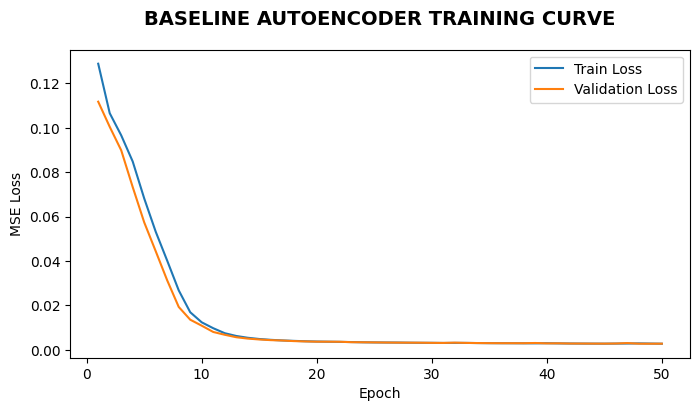

2026-08-18 15:13:03.051538: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Best observed validation loss : 0.002740 (epoch 49)
AE validation threshold       : 0.00324221
Validation flag rate          : 4.76% (target ≤ 5.00%)

✅ BLOCK 7 COMPLETED: Autoencoder trained with deterministic epoch shuffling and calibrated without final-test scoring.


In [7]:
# ==========================================================================================================================================================
# BLOCK 7: BASELINE AUTOENCODER TRAINING & VALIDATION CALIBRATION
# ==========================================================================================================================================================

print("INITIATING BASELINE AUTOENCODER TRAINING...\n")

print(
    f"ACTION: Normal-only reconstruction training for {BASELINE_EPOCHS} epochs "
    f"with batch size {BASELINE_BATCH_SIZE}, followed by validation-only threshold calibration.\n"
)


# UPSTREAM DEPENDENCY AUDIT

_required_block_7_objects = [
    "model",
    "train_images",
    "validation_images",
    "BASELINE_EPOCHS",
    "BASELINE_BATCH_SIZE",
    "TARGET_VALIDATION_FPR",
    "calibrate_normal_threshold",
    "SEED",
    "reset_reproducibility",
]

_missing_block_7_objects = [
    object_name
    for object_name in _required_block_7_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_7_objects:
    raise RuntimeError(
        "BLOCK 7 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_7_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


# RECONSTRUCTION ANOMALY-SCORE FUNCTION

def reconstruction_mse(images, reconstructions):
    """Return one scalar reconstruction-MSE anomaly score per sample."""

    if images.shape != reconstructions.shape:
        raise ValueError(
            f"Reconstruction shape mismatch: input={images.shape}, "
            f"output={reconstructions.shape}"
        )

    scores = np.mean(
        np.square(
            images - reconstructions
        ),
        axis=(1, 2, 3),
    )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Non-finite reconstruction anomaly scores detected."
        )

    return scores


# DETERMINISTIC TRAINING BOUNDARY

reset_reproducibility(
    SEED,
    clear_session=False,
)


# DETERMINISTIC TRAINING PIPELINE
# Samples are reshuffled each epoch, but the full shuffle sequence is seeded.

dataset_options = tf.data.Options()
dataset_options.experimental_deterministic = True

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_images,
        train_images,
    )
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(train_images),
    seed=SEED,
    reshuffle_each_iteration=True,
)

train_dataset = train_dataset.batch(
    BASELINE_BATCH_SIZE,
    drop_remainder=False,
)

train_dataset = train_dataset.with_options(
    dataset_options
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (
        validation_images,
        validation_images,
    )
)

validation_dataset = validation_dataset.batch(
    BASELINE_BATCH_SIZE,
    drop_remainder=False,
)

validation_dataset = validation_dataset.with_options(
    dataset_options
)


# BASELINE TRAINING

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=BASELINE_EPOCHS,
    verbose=1,
)


# TRAINING HISTORY INTEGRITY

train_loss = np.asarray(
    history.history.get(
        "loss",
        [],
    ),
    dtype=float,
)

validation_loss = np.asarray(
    history.history.get(
        "val_loss",
        [],
    ),
    dtype=float,
)

if (
    len(train_loss) != BASELINE_EPOCHS
    or len(validation_loss) != BASELINE_EPOCHS
    or not np.isfinite(train_loss).all()
    or not np.isfinite(validation_loss).all()
):
    raise RuntimeError(
        "BLOCK 7 TRAINING FAILURE: incomplete or non-finite training history."
    )


best_validation_epoch = int(
    np.argmin(
        validation_loss
    )
) + 1

best_validation_loss = float(
    np.min(
        validation_loss
    )
)


# LEARNING-CURVE VISUALIZATION

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    np.arange(
        1,
        len(train_loss) + 1,
    ),
    train_loss,
    label="Train Loss",
)

plt.plot(
    np.arange(
        1,
        len(validation_loss) + 1,
    ),
    validation_loss,
    label="Validation Loss",
)

plt.title(
    "BASELINE AUTOENCODER TRAINING CURVE",
    fontsize=14,
    fontweight="bold",
    pad=18,
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


# VALIDATION-ONLY ANOMALY THRESHOLD

validation_reconstructions = model.predict(
    validation_images,
    batch_size=BASELINE_BATCH_SIZE,
    verbose=0,
)

ae_validation_scores = reconstruction_mse(
    validation_images,
    validation_reconstructions,
)

ae_threshold, ae_validation_flag_rate = calibrate_normal_threshold(
    ae_validation_scores,
    TARGET_VALIDATION_FPR,
)


print(
    f"\nBest observed validation loss : {best_validation_loss:.6f} "
    f"(epoch {best_validation_epoch})"
)

print(
    f"AE validation threshold       : {ae_threshold:.8f}"
)

print(
    f"Validation flag rate          : {ae_validation_flag_rate:.2%} "
    f"(target ≤ {TARGET_VALIDATION_FPR:.2%})"
)

print(
    "\n✅ BLOCK 7 COMPLETED: "
    "Autoencoder trained with deterministic epoch shuffling and calibrated without final-test scoring."
)


### BLOCK 8: FINAL TEST EVALUATION, ERROR ANALYSIS & QUALITATIVE RESIDUAL MAPS

**OBJECTIVE:**  
Evaluate both fixed baseline models on the final MVTec test set after model fitting and validation-only threshold calibration are complete.

**UNIFIED EVALUATION:**
- **SVM anomaly score:** negative One-Class SVM decision value.
- **Autoencoder anomaly score:** per-image reconstruction MSE.
- Both scores follow the notebook-wide contract: **higher score = more anomalous**.
- ROC-AUC is computed from continuous scores.
- Binary operational metrics reuse thresholds calibrated exclusively from held-out normal validation data.
- Per-defect evaluation reuses those same fixed thresholds.

**FINAL-TEST VISUAL AUDIT:**
- Normal and anomalous images are compared **within the same test distribution** (`test_good` vs `test_bad`).
- Pixel-intensity distributions are normalized (`density=True`) so unequal group sizes remain comparable.
- SVM+PCA and Simple AE are shown on the **same ROC axes** for direct threshold-free comparison.

**QUALITATIVE RESIDUAL ANALYSIS:**
- One representative anomalous sample is selected per defect category when possible.
- Reconstruction-residual heatmaps use a shared robust intensity scale across the displayed samples.
- The overlay is treated as qualitative evidence only; no claim of pixel-accurate defect localization is made without quantitative comparison against MVTec ground-truth masks.


OPENING FINAL TEST EVALUATION...

ACTION: Scoring both fixed baselines on the final test set, performing defect-wise evaluation and qualitative residual analysis.

UNIFIED FINAL TEST METRICS


,roc_auc,threshold,balanced_accuracy,precision,recall,f1,test_false_positive_rate,tn,fp,fn,tp
model,,,,,,,,,,,
SVM+PCA,0.561905,0.059391,0.563492,1.000000,0.126984,0.225352,0.00,20,0,55,8
Simple AE,0.544444,0.003242,0.541667,0.807692,0.333333,0.471910,0.25,15,5,42,21


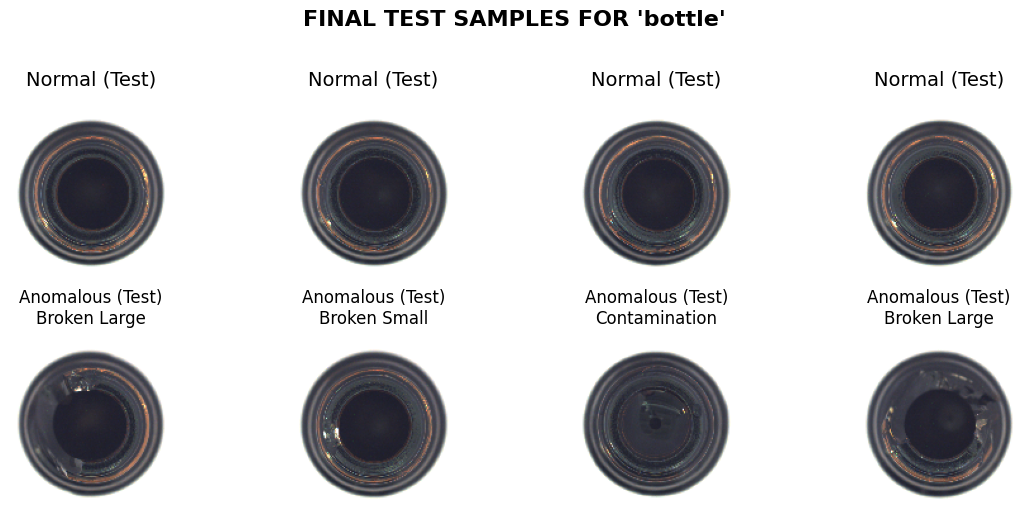

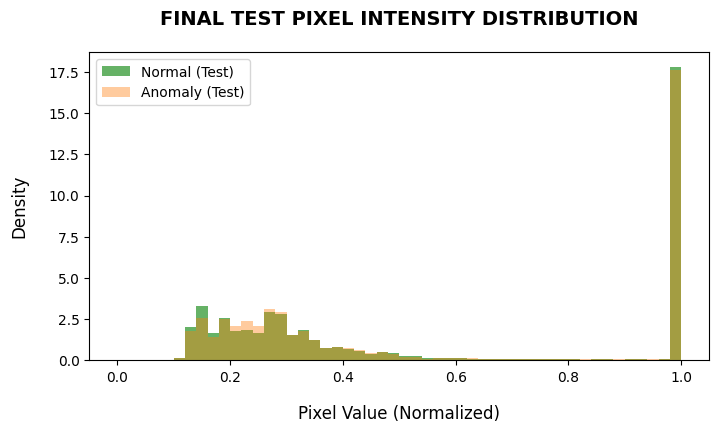

,group,samples,mean_pixel_intensity,std_pixel_intensity
0,Normal (Test),20,0.543678,0.360112
1,Anomaly (Test),63,0.543614,0.357797


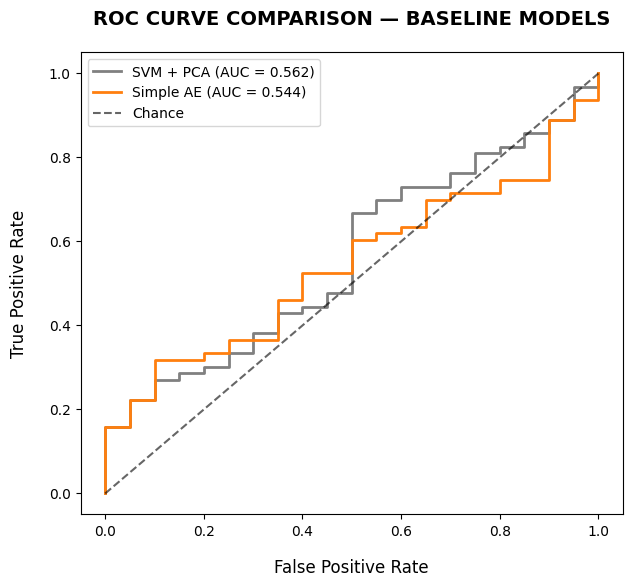


PER-DEFECT FINAL TEST ANALYSIS


,model,defect_category,defect_samples,roc_auc_vs_good,detection_rate_at_threshold
0,SVM+PCA,broken_large,20,0.567500,0.150000
1,SVM+PCA,broken_small,22,0.468182,0.045455
2,SVM+PCA,contamination,21,0.654762,0.190476
3,Simple AE,broken_large,20,0.472500,0.200000
4,Simple AE,broken_small,22,0.620455,0.409091
5,Simple AE,contamination,21,0.533333,0.380952




Visualizing Qualitative Reconstruction Residuals...



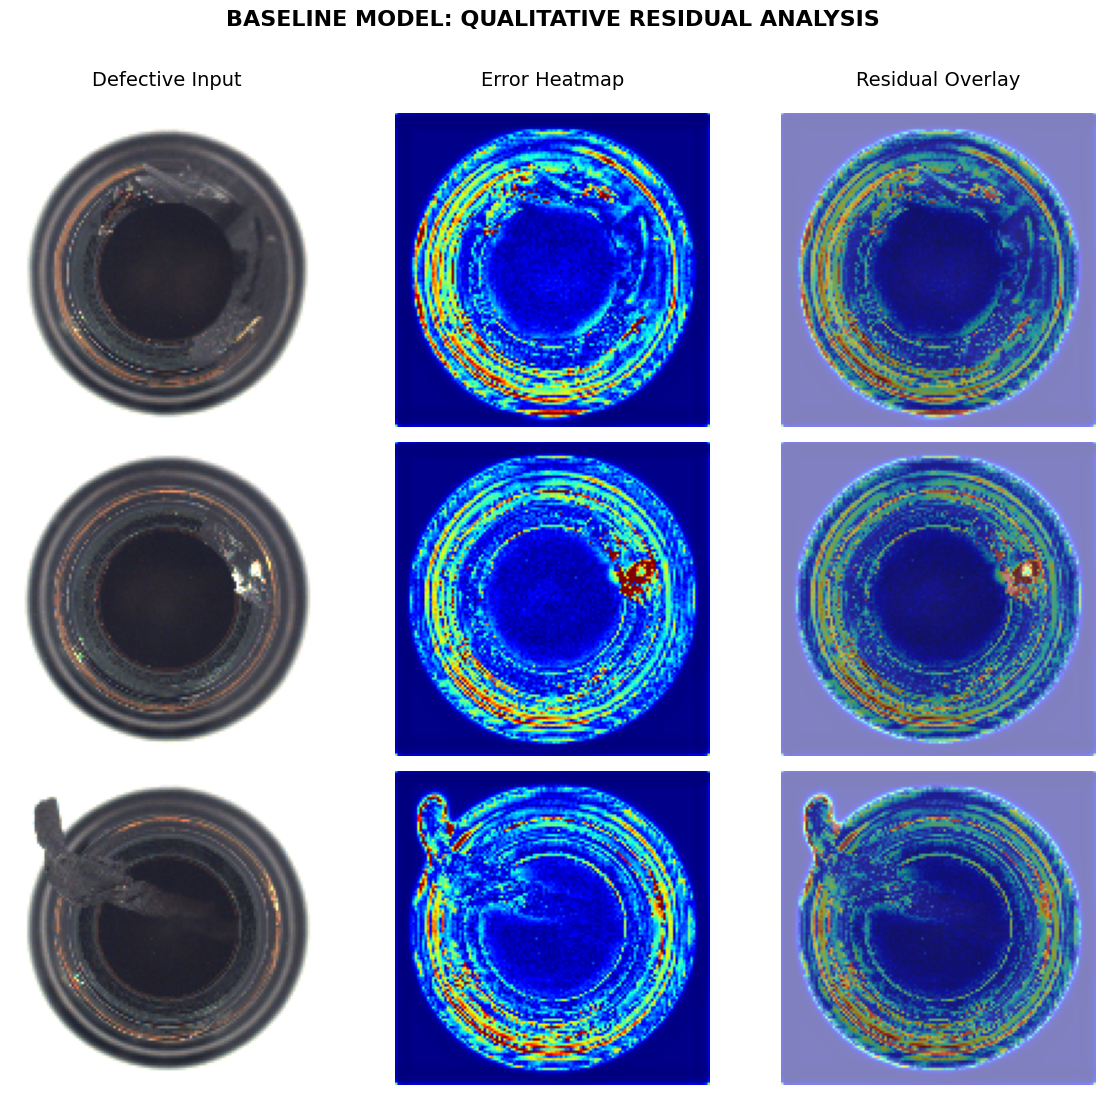


NOTE: Residual maps use one shared 99th-percentile intensity scale across the displayed defect categories. They are qualitative reconstruction-error visualizations, not quantitative proof of pixel-accurate localization.

✅ BLOCK 8 COMPLETED: Final test evaluation, defect-wise analysis and qualitative residual reporting completed.


In [8]:
# ==========================================================================================================================================================
# BLOCK 8: FINAL TEST EVALUATION, ERROR ANALYSIS & QUALITATIVE RESIDUAL MAPS
# ==========================================================================================================================================================

print("OPENING FINAL TEST EVALUATION...\n")

print(
    "ACTION: Scoring both fixed baselines on the final test set, "
    "performing defect-wise evaluation and qualitative residual analysis.\n"

)


# UPSTREAM DEPENDENCY AUDIT

_required_block_8_objects = [
    "test_images",
    "test_labels",
    "test_categories",
    "test_good",
    "test_bad",
    "test_bad_categories",
    "defect_categories",
    "pca_model",
    "svm_model",
    "svm_threshold",
    "model",
    "ae_threshold",
    "reconstruction_mse",
    "NORMAL_LABEL",
    "ANOMALY_LABEL",
    "BASELINE_BATCH_SIZE",
    "TARGET_CLASS",
    "SEED",
]

_missing_block_8_objects = [
    object_name
    for object_name in _required_block_8_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_8_objects:
    raise RuntimeError(
        "BLOCK 8 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_8_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


# OPERATIONAL-METRIC FUNCTION

def compute_operational_metrics(
    y_true,
    anomaly_scores,
    threshold,
):
    """Compute thresholded metrics under the 0=good, 1=anomaly contract."""

    predictions = (
        anomaly_scores > threshold
    ).astype(np.int8)

    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=[
            NORMAL_LABEL,
            ANOMALY_LABEL,
        ],
    )

    tn, fp, fn, tp = matrix.ravel()

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="binary",
        pos_label=ANOMALY_LABEL,
        zero_division=0,
    )

    false_positive_rate = fp / max(
        fp + tn,
        1,
    )

    return {
        "roc_auc": float(
            roc_auc_score(
                y_true,
                anomaly_scores,
            )
        ),
        "threshold": float(threshold),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions,
            )
        ),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "test_false_positive_rate": float(
            false_positive_rate
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


# 1. CLASSICAL BASELINE — FINAL TEST SCORES

test_flat = test_images.reshape(
    len(test_images),
    -1,
)

test_pca = pca_model.transform(
    test_flat
)

if not np.isfinite(test_pca).all():
    raise RuntimeError(
        "BLOCK 8 PCA FAILURE: non-finite final-test PCA features detected."
    )

svm_test_scores = -svm_model.decision_function(
    test_pca
)

if not np.isfinite(svm_test_scores).all():
    raise RuntimeError(
        "BLOCK 8 SVM FAILURE: non-finite final-test anomaly scores detected."
    )

svm_auc = float(
    roc_auc_score(
        test_labels,
        svm_test_scores,
    )
)

svm_fpr, svm_tpr, _ = roc_curve(
    test_labels,
    svm_test_scores,
)


# 2. AUTOENCODER BASELINE — FINAL TEST SCORES

test_reconstructions = model.predict(
    test_images,
    batch_size=BASELINE_BATCH_SIZE,
    verbose=0,
)

ae_test_scores = reconstruction_mse(
    test_images,
    test_reconstructions,
)

ae_auc = float(
    roc_auc_score(
        test_labels,
        ae_test_scores,
    )
)

ae_fpr, ae_tpr, _ = roc_curve(
    test_labels,
    ae_test_scores,
)


# 3. UNIFIED OPERATIONAL METRICS

svm_metrics = compute_operational_metrics(
    test_labels,
    svm_test_scores,
    svm_threshold,
)

ae_metrics = compute_operational_metrics(
    test_labels,
    ae_test_scores,
    ae_threshold,
)

metrics_df = pd.DataFrame(
    [
        {
            "model": "SVM+PCA",
            **svm_metrics,
        },
        {
            "model": "Simple AE",
            **ae_metrics,
        },
    ]
).set_index(
    "model"
)

print("UNIFIED FINAL TEST METRICS")
display(metrics_df)


# ==========================================================================================================================================================
# 4. FINAL TEST DATASET VISUAL AUDIT
# ==========================================================================================================================================================
# Compare normal and anomalous samples inside the same final-test distribution.
# This avoids mixing train/test distribution differences with normal/anomaly differences.

rng_visual = np.random.default_rng(SEED)

n_samples = min(
    4,
    len(test_good),
    len(test_bad),
)

good_sample_indices = rng_visual.choice(
    len(test_good),
    size=n_samples,
    replace=False,
)


def select_diverse_anomaly_indices(categories, sample_count, seed):
    """Select deterministic anomaly examples while maximizing defect-category coverage."""

    categories = np.asarray(categories, dtype=object)

    if len(categories) == 0:
        raise ValueError("No anomalous categories are available for visualization.")

    rng_local = np.random.default_rng(seed)
    selected = []

    unique_categories = sorted(
        str(category)
        for category in np.unique(categories)
    )

    # First pass: one sample from each defect category.
    for category in unique_categories:

        category_indices = np.flatnonzero(
            categories == category
        )

        if len(category_indices) == 0:
            continue

        selected.append(
            int(
                rng_local.choice(
                    category_indices
                )
            )
        )

        if len(selected) == sample_count:
            return np.asarray(selected, dtype=int)

    # Second pass: fill any remaining positions without replacement.
    remaining_indices = np.setdiff1d(
        np.arange(len(categories)),
        np.asarray(selected, dtype=int),
        assume_unique=False,
    )

    remaining_needed = sample_count - len(selected)

    if remaining_needed > 0:

        additional = rng_local.choice(
            remaining_indices,
            size=remaining_needed,
            replace=False,
        )

        selected.extend(
            int(index)
            for index in np.atleast_1d(additional)
        )

    return np.asarray(
        selected,
        dtype=int,
    )


bad_sample_indices = select_diverse_anomaly_indices(
    test_bad_categories,
    n_samples,
    SEED + 1,
)


# SAMPLE GRID

plt.figure(
    figsize=(12, 5)
)

plt.suptitle(
    f"FINAL TEST SAMPLES FOR '{TARGET_CLASS}'",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.subplots_adjust(
    top=0.88,
    hspace=0.6,
)


for i, idx in enumerate(good_sample_indices):

    plt.subplot(
        2,
        n_samples,
        i + 1,
    )

    plt.imshow(
        test_good[idx]
    )

    plt.title(
        "Normal (Test)",
        fontsize=14,
        pad=20,
    )

    plt.axis("off")


for i, idx in enumerate(bad_sample_indices):

    plt.subplot(
        2,
        n_samples,
        i + 1 + n_samples,
    )

    plt.imshow(
        test_bad[idx]
    )

    category_label = str(
        test_bad_categories[idx]
    ).replace(
        "_",
        " ",
    ).title()

    plt.title(
        f"Anomalous (Test)\n{category_label}",
        fontsize=12,
        pad=14,
    )

    plt.axis("off")


plt.tight_layout()
plt.show()


# FINAL-TEST PIXEL-INTENSITY DISTRIBUTION
# density=True prevents unequal sample counts from driving histogram height.

common_bins = np.linspace(
    0.0,
    1.0,
    51,
)

plt.figure(
    figsize=(8, 4)
)

plt.hist(
    test_good.ravel(),
    bins=common_bins,
    density=True,
    color="green",
    alpha=0.6,
    label="Normal (Test)",
)

plt.hist(
    test_bad.ravel(),
    bins=common_bins,
    density=True,
    color="#ff7f0e",
    alpha=0.4,
    label="Anomaly (Test)",
)

plt.title(
    "FINAL TEST PIXEL INTENSITY DISTRIBUTION",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Pixel Value (Normalized)",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "Density",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


final_visual_summary = pd.DataFrame(
    [
        {
            "group": "Normal (Test)",
            "samples": int(len(test_good)),
            "mean_pixel_intensity": float(test_good.mean()),
            "std_pixel_intensity": float(test_good.std()),
        },
        {
            "group": "Anomaly (Test)",
            "samples": int(len(test_bad)),
            "mean_pixel_intensity": float(test_bad.mean()),
            "std_pixel_intensity": float(test_bad.std()),
        },
    ]
)

display(
    final_visual_summary
)


# ==========================================================================================================================================================
# 5. ROC CURVE COMPARISON
# ==========================================================================================================================================================
# Both baselines share the same axes because ROC-AUC is the primary threshold-free ranking metric.

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    svm_fpr,
    svm_tpr,
    color="grey",
    lw=2,
    label=f"SVM + PCA (AUC = {svm_auc:.3f})",
)

plt.plot(
    ae_fpr,
    ae_tpr,
    color="#ff7f0e",
    lw=2,
    label=f"Simple AE (AUC = {ae_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    alpha=0.6,
    label="Chance",
)

plt.title(
    "ROC CURVE COMPARISON — BASELINE MODELS",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# ==========================================================================================================================================================
# 6. PER-DEFECT ANALYSIS
# ==========================================================================================================================================================

def build_per_defect_report(
    model_name,
    scores,
    threshold,
):
    """Evaluate each defect category against the same good-test reference group."""

    report_rows = []

    good_mask = (
        test_categories == "good"
    )

    good_scores = scores[
        good_mask
    ]

    for category in defect_categories:

        defect_mask = (
            test_categories == category
        )

        defect_scores = scores[
            defect_mask
        ]

        category_labels = np.concatenate(
            (
                np.full(
                    len(good_scores),
                    NORMAL_LABEL,
                    dtype=np.int8,
                ),
                np.full(
                    len(defect_scores),
                    ANOMALY_LABEL,
                    dtype=np.int8,
                ),
            )
        )

        category_scores = np.concatenate(
            (
                good_scores,
                defect_scores,
            )
        )

        report_rows.append(
            {
                "model": model_name,
                "defect_category": category,
                "defect_samples": int(
                    len(defect_scores)
                ),
                "roc_auc_vs_good": float(
                    roc_auc_score(
                        category_labels,
                        category_scores,
                    )
                ),
                "detection_rate_at_threshold": float(
                    np.mean(
                        defect_scores > threshold
                    )
                ),
            }
        )

    return report_rows


per_defect_metrics = pd.DataFrame(
    build_per_defect_report(
        "SVM+PCA",
        svm_test_scores,
        svm_threshold,
    )
    +
    build_per_defect_report(
        "Simple AE",
        ae_test_scores,
        ae_threshold,
    )
)

print(
    "\nPER-DEFECT FINAL TEST ANALYSIS"
)

display(
    per_defect_metrics
)


# ==========================================================================================================================================================
# 7. QUALITATIVE RECONSTRUCTION-RESIDUAL ANALYSIS
# ==========================================================================================================================================================
# Residual maps are qualitative. A shared robust scale makes cross-image intensity comparable.

anomaly_mask = (
    test_labels == ANOMALY_LABEL
)

bad_reconstructions = test_reconstructions[
    anomaly_mask
]

if len(bad_reconstructions) != len(test_bad):
    raise RuntimeError(
        "BLOCK 8 ALIGNMENT FAILURE: anomalous reconstructions are misaligned."
    )


def compute_residual_map(
    original,
    reconstructed,
):
    """Return the channel-averaged absolute reconstruction residual."""

    residual_map = np.mean(
        np.abs(
            original - reconstructed
        ),
        axis=-1,
    )

    if not np.isfinite(residual_map).all():
        raise RuntimeError(
            "BLOCK 8 RESIDUAL FAILURE: non-finite residual values detected."
        )

    return residual_map


# Select one deterministic representative per defect category when possible.

representative_indices = []

rng_heatmap = np.random.default_rng(
    SEED + 2
)

for category in defect_categories:

    category_indices = np.flatnonzero(
        test_bad_categories == category
    )

    if len(category_indices) == 0:
        continue

    representative_indices.append(
        int(
            rng_heatmap.choice(
                category_indices
            )
        )
    )


if not representative_indices:
    raise RuntimeError(
        "BLOCK 8 RESIDUAL FAILURE: no anomalous samples available for qualitative analysis."
    )


selected_error_maps = [
    compute_residual_map(
        test_bad[index],
        bad_reconstructions[index],
    )
    for index in representative_indices
]


shared_vmax = float(
    np.quantile(
        np.concatenate(
            [
                error_map.ravel()
                for error_map in selected_error_maps
            ]
        ),
        0.99,
    )
)

shared_vmax = max(
    shared_vmax,
    np.finfo(np.float32).eps,
)


print(
    "\n\nVisualizing Qualitative Reconstruction Residuals...\n"
)


n_show = len(
    representative_indices
)

plt.figure(
    figsize=(12, 3.6 * n_show)
)

plt.suptitle(
    "BASELINE MODEL: QUALITATIVE RESIDUAL ANALYSIS",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)


for row_index, sample_index in enumerate(representative_indices):

    original = test_bad[
        sample_index
    ]

    error_map = selected_error_maps[
        row_index
    ]

    category_label = str(
        test_bad_categories[
            sample_index
        ]
    ).replace(
        "_",
        " ",
    ).title()


    # DEFECTIVE INPUT

    ax = plt.subplot(
        n_show,
        3,
        row_index * 3 + 1,
    )

    ax.imshow(
        original
    )

    if row_index == 0:
        ax.set_title(
            "Defective Input",
            fontsize=14,
            pad=20,
        )

    ax.set_ylabel(
        category_label,
        fontsize=11,
        labelpad=12,
    )

    ax.axis("off")


    # ERROR HEATMAP

    ax = plt.subplot(
        n_show,
        3,
        row_index * 3 + 2,
    )

    ax.imshow(
        error_map,
        cmap="jet",
        vmin=0.0,
        vmax=shared_vmax,
    )

    if row_index == 0:
        ax.set_title(
            "Error Heatmap",
            fontsize=14,
            pad=20,
        )

    ax.axis("off")


    # RESIDUAL OVERLAY

    ax = plt.subplot(
        n_show,
        3,
        row_index * 3 + 3,
    )

    ax.imshow(
        original
    )

    ax.imshow(
        error_map,
        cmap="jet",
        alpha=0.50,
        vmin=0.0,
        vmax=shared_vmax,
    )

    if row_index == 0:
        ax.set_title(
            "Residual Overlay",
            fontsize=14,
            pad=20,
        )

    ax.axis("off")


plt.tight_layout()
plt.show()


print(
    "\nNOTE: Residual maps use one shared 99th-percentile intensity scale across the displayed defect categories. "
    "They are qualitative reconstruction-error visualizations, not quantitative proof of pixel-accurate localization."
)

print(
    "\n✅ BLOCK 8 COMPLETED: Final test evaluation, defect-wise analysis "
    "and qualitative residual reporting completed."
)


### BLOCK 9: BASELINE COMPARISON & SCIENTIFIC CONCLUSION

**OBJECTIVE:**  
Summarize the two baseline experiments without over-generalizing beyond the evidence produced by this notebook.

**COMPARISON RULES:**
- ROC-AUC is the primary threshold-free ranking metric.
- Operational metrics are reported at thresholds selected before test evaluation.
- A small numerical AUC difference is treated descriptively and is not presented as proof of statistically established superiority.
- A model winning this experiment does not imply that its entire model family is universally superior.

The final comparison establishes the baseline performance floor that later notebooks must improve upon.


ASSEMBLING BASELINE COMPARISON...

ACTION: Consolidating ROC-AUC and operational metrics into the Notebook 1 conclusion.



,roc_auc,balanced_accuracy,precision,recall,f1,test_false_positive_rate,auc_delta_vs_svm
model,,,,,,,
SVM+PCA,0.561905,0.563492,1.000000,0.126984,0.225352,0.00,0.00000
Simple AE,0.544444,0.541667,0.807692,0.333333,0.471910,0.25,-0.01746


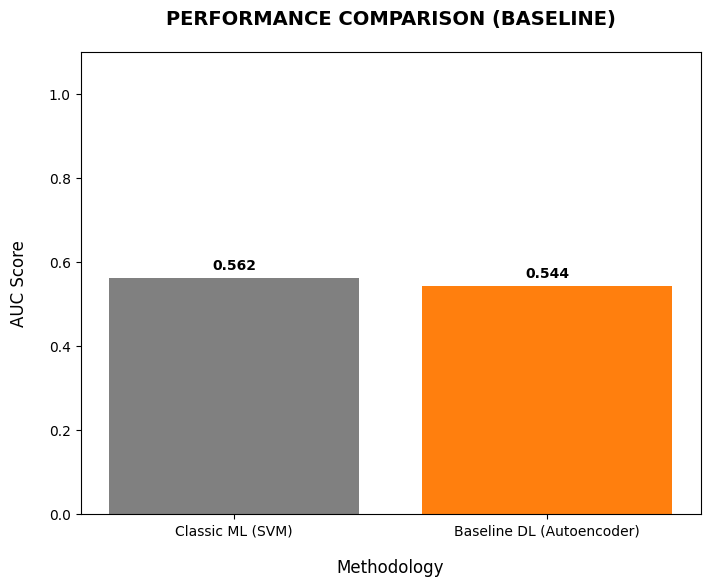

SCIENTIFIC CONCLUSION
The SVM+PCA baseline achieved a numerically higher ROC-AUC by 0.0175 in this fixed experiment. Given the limited test-set size and the small observed difference, this result is interpreted descriptively rather than as evidence of statistically established superiority. It establishes the classical baseline that subsequent models must attempt to exceed.

✅ BLOCK 9 COMPLETED: Baseline comparison finalized with conservative experiment-scoped interpretation.


In [9]:
# ==========================================================================================================================================================
# BLOCK 9: BASELINE COMPARISON & SCIENTIFIC CONCLUSION
# ==========================================================================================================================================================

print("ASSEMBLING BASELINE COMPARISON...\n")
print("ACTION: Consolidating ROC-AUC and operational metrics into the Notebook 1 conclusion.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_9_objects = ['metrics_df', 'svm_auc', 'ae_auc']
_missing_block_9_objects = [
    object_name
    for object_name in _required_block_9_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_9_objects:
    raise RuntimeError(
        "BLOCK 9 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_9_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


comparison_df = metrics_df[
    [
        "roc_auc",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "test_false_positive_rate",
    ]
].copy()

comparison_df["auc_delta_vs_svm"] = comparison_df["roc_auc"] - svm_auc

display(comparison_df)


# BASELINE ROC-AUC COMPARISON
# Provides a direct visual comparison of the two fixed baseline methods.

models = ['Classic ML (SVM)', 'Baseline DL (Autoencoder)']
scores = [svm_auc, ae_auc]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, scores, color=['grey', '#ff7f0e'])
plt.title('PERFORMANCE COMPARISON (BASELINE)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Methodology', fontsize=12, labelpad=15)
plt.ylabel('AUC Score', fontsize=12, labelpad=15)
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f'{yval:.3f}',
        ha='center',
        fontweight='bold'
    )

plt.show()


# EXPERIMENT-SCOPED VERDICT

auc_delta = ae_auc - svm_auc

if np.isclose(auc_delta, 0.0, atol=1e-6):

    conclusion = (
        "The two baseline methods achieved effectively identical ROC-AUC in this experiment."
    )

elif auc_delta > 0:

    conclusion = (
        f"The Simple AE achieved a numerically higher ROC-AUC by {auc_delta:.4f} in this fixed experiment. "
        "Given the limited test-set size and the small observed difference, this result is interpreted descriptively "
        "rather than as evidence of statistically established superiority. "
        "The result nevertheless provides the reference baseline for the later deep-learning optimization stages."
    )

else:

    conclusion = (
        f"The SVM+PCA baseline achieved a numerically higher ROC-AUC by {abs(auc_delta):.4f} in this fixed experiment. "
        "Given the limited test-set size and the small observed difference, this result is interpreted descriptively "
        "rather than as evidence of statistically established superiority. "
        "It establishes the classical baseline that subsequent models must attempt to exceed."
    )


print("SCIENTIFIC CONCLUSION")
print(conclusion)

print(
    "\n✅ BLOCK 9 COMPLETED: Baseline comparison finalized with conservative experiment-scoped interpretation."
)


### BLOCK 10: ARTIFACT & METRIC EXPORT

**OBJECTIVE:**  
Persist the fitted Notebook 1 baselines and their evaluation metadata in a portable, traceable contract for downstream notebooks.

**EXPORTED ARTIFACTS:**
- PCA model (`joblib`)
- One-Class SVM model (`joblib`)
- Simple Autoencoder (`.keras`)
- Per-defect evaluation table (`.csv`)
- Baseline experiment contract (`baseline_metrics.json`)

**TRACEABILITY CONTRACT:**
The JSON records:
- experiment configuration and label/score semantics,
- train/validation/final-test sample counts,
- defect-category counts,
- validation threshold policy and observed validation flag rates,
- final evaluation metrics,
- relative artifact references.

Artifact paths are stored relative to the directory containing `baseline_metrics.json`, avoiding hard-coded runtime paths.


In [10]:
# ==========================================================================================================================================================
# BLOCK 10: ARTIFACT & METRIC EXPORT
# ==========================================================================================================================================================

print("EXPORTING NOTEBOOK 1 BASELINE ARTIFACTS...\n")
print("ACTION: Persisting models, metrics and portable cross-notebook metadata.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_10_objects = [
    "ARTIFACT_DIR",
    "BASELINE_METRICS_PATH",
    "KAGGLE_WORK_ROOT",
    "pca_model",
    "svm_model",
    "model",
    "per_defect_metrics",
    "svm_auc",
    "ae_auc",
    "svm_metrics",
    "ae_metrics",
    "train_pca",
    "retained_variance",
    "latent_shape",
    "compression_ratio",
    "TARGET_CLASS",
    "IMG_SIZE",
    "SEED",
    "NORMAL_LABEL",
    "ANOMALY_LABEL",
    "TARGET_VALIDATION_FPR",
    "PCA_VARIANCE_TARGET",
    "OCSVM_NU",
    "OCSVM_GAMMA",
    "BASELINE_EPOCHS",
    "BASELINE_BATCH_SIZE",
    "BASELINE_LEARNING_RATE",
    "train_images",
    "validation_images",
    "test_good",
    "test_bad",
    "test_bad_categories",
    "svm_validation_flag_rate",
    "ae_validation_flag_rate",
    "Path",
    "joblib",
    "json",
    "pd",
    "np",
]

_missing_block_10_objects = [
    object_name
    for object_name in _required_block_10_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_10_objects:
    raise RuntimeError(
        "BLOCK 10 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_10_objects}. "
        "Run the notebook sequentially from Block 1 in the current kernel; "
        "if using Run All, inspect the FIRST earlier error before this block."
    )


# ARTIFACT PATH CONFIGURATION

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PCA_MODEL_PATH = (
    ARTIFACT_DIR
    / "pca_baseline.joblib"
)

SVM_MODEL_PATH = (
    ARTIFACT_DIR
    / "one_class_svm_baseline.joblib"
)

AE_MODEL_PATH = (
    ARTIFACT_DIR
    / "simple_ae_baseline.keras"
)

PER_DEFECT_METRICS_PATH = (
    ARTIFACT_DIR
    / "per_defect_metrics.csv"
)


# PORTABLE PATH HELPER

def to_portable_relative_path(path):
    """
    Store artifact paths relative to the directory containing baseline_metrics.json.

    Downstream notebooks can resolve them after Notebook 1 outputs are
    mounted under any Kaggle input path.
    """

    path = Path(
        path
    )

    try:
        return path.relative_to(
            BASELINE_METRICS_PATH.parent
        ).as_posix()

    except ValueError as exc:
        raise RuntimeError(
            "BLOCK 10 PATH FAILURE: artifact is outside the metrics-contract directory: "
            f"{path}"
        ) from exc


# MODEL EXPORT

joblib.dump(
    pca_model,
    PCA_MODEL_PATH,
)

joblib.dump(
    svm_model,
    SVM_MODEL_PATH,
)

model.save(
    AE_MODEL_PATH
)

per_defect_metrics.to_csv(
    PER_DEFECT_METRICS_PATH,
    index=False,
)


# PORTABLE ARTIFACT REFERENCES

portable_artifacts = {
    "pca_model": to_portable_relative_path(
        PCA_MODEL_PATH
    ),
    "svm_model": to_portable_relative_path(
        SVM_MODEL_PATH
    ),
    "simple_ae_model": to_portable_relative_path(
        AE_MODEL_PATH
    ),
    "per_defect_metrics": to_portable_relative_path(
        PER_DEFECT_METRICS_PATH
    ),
}


# CROSS-NOTEBOOK METRIC CONTRACT

defect_sample_counts = {
    str(category): int(np.sum(test_bad_categories == category))
    for category in sorted(np.unique(test_bad_categories))
}

baseline_metrics = {
    "schema_version": "2.1",

    "target_class": TARGET_CLASS,

    "img_size": list(
        IMG_SIZE
    ),

    "seed": SEED,

    "label_contract": {
        "good": NORMAL_LABEL,
        "anomaly": ANOMALY_LABEL,
    },

    "score_contract": (
        "higher_score_means_more_anomalous"
    ),

    "dataset_summary": {
        "train_normal": int(len(train_images)),
        "validation_normal": int(len(validation_images)),
        "test_normal": int(len(test_good)),
        "test_anomaly": int(len(test_bad)),
        "test_defect_categories": defect_sample_counts,
    },

    "threshold_policy": {
        "source": "held_out_normal_validation_only",
        "validation_samples": int(len(validation_images)),
        "target_validation_false_positive_rate": TARGET_VALIDATION_FPR,
        "empirical_quantile_method": "higher",
        "decision_rule": "score > threshold",
    },

    # Direct compatibility with Notebook 4.
    "svm_pca": float(
        svm_auc
    ),

    "simple_ae": float(
        ae_auc
    ),

    "models": {

        "svm_pca": {
            **svm_metrics,

            "pca_variance_target": PCA_VARIANCE_TARGET,

            "pca_components": int(
                train_pca.shape[1]
            ),

            "pca_retained_variance": float(
                retained_variance
            ),

            "ocsvm_nu": OCSVM_NU,

            "ocsvm_gamma": OCSVM_GAMMA,
            "validation_flag_rate": float(svm_validation_flag_rate),
        },

        "simple_ae": {
            **ae_metrics,

            "epochs": BASELINE_EPOCHS,

            "batch_size": BASELINE_BATCH_SIZE,

            "learning_rate": BASELINE_LEARNING_RATE,

            "latent_shape": list(
                latent_shape
            ),

            "compression_ratio": float(
                compression_ratio
            ),

            "validation_flag_rate": float(
                ae_validation_flag_rate
            ),
        },
    },

    "artifact_path_policy": (
        "paths_are_relative_to_the_directory_containing_baseline_metrics_json"
    ),

    "artifacts": portable_artifacts,
}


# JSON EXPORT

with BASELINE_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        baseline_metrics,
        file,
        indent=2,
        sort_keys=True,
    )


# ARTIFACT VERIFICATION

artifact_paths = [
    BASELINE_METRICS_PATH,
    PCA_MODEL_PATH,
    SVM_MODEL_PATH,
    AE_MODEL_PATH,
    PER_DEFECT_METRICS_PATH,
]

artifact_audit = pd.DataFrame(
    [
        {
            "artifact": path.name,

            "exists": path.is_file(),

            "size_kb": (
                round(
                    path.stat().st_size / 1024.0,
                    2,
                )
                if path.is_file()
                else np.nan
            ),

            "portable_path": (
                path.name
                if path == BASELINE_METRICS_PATH
                else to_portable_relative_path(
                    path
                )
            ),

            "runtime_path": str(
                path
            ),
        }

        for path in artifact_paths
    ]
)


if not artifact_audit[
    "exists"
].all():

    missing = artifact_audit.loc[
        ~artifact_audit["exists"],
        "artifact",
    ].tolist()

    raise RuntimeError(
        "BLOCK 10 EXPORT FAILURE: "
        f"missing artifacts: {missing}"
    )


display(
    artifact_audit
)

print(
    f"\nPrimary metrics contract: {BASELINE_METRICS_PATH}"
)

print(
    "\n✅ BLOCK 10 COMPLETED: Notebook 1 baseline models, metrics "
    "and portable artifact references exported successfully."
)


EXPORTING NOTEBOOK 1 BASELINE ARTIFACTS...

ACTION: Persisting models, metrics and portable cross-notebook metadata.



,artifact,exists,size_kb,portable_path,runtime_path
0,baseline_metrics.json,True,2.29,baseline_metrics.json,/kaggle/working/baseline_metrics.json
1,pca_baseline.joblib,True,24002.41,notebook1_artifacts/pca_baseline.joblib,/kaggle/working/notebook1_artifacts/pca_baseli...
2,one_class_svm_baseline.joblib,True,59.69,notebook1_artifacts/one_class_svm_baseline.joblib,/kaggle/working/notebook1_artifacts/one_class_...
3,simple_ae_baseline.keras,True,204.72,notebook1_artifacts/simple_ae_baseline.keras,/kaggle/working/notebook1_artifacts/simple_ae_...
4,per_defect_metrics.csv,True,0.43,notebook1_artifacts/per_defect_metrics.csv,/kaggle/working/notebook1_artifacts/per_defect...



Primary metrics contract: /kaggle/working/baseline_metrics.json

✅ BLOCK 10 COMPLETED: Notebook 1 baseline models, metrics and portable artifact references exported successfully.
